<a href="https://colab.research.google.com/github/majnumiah1588/AI_Lab/blob/main/notebooks/CNN_BinaryClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, random, zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/leaf_dataset/dataset.zip"

Mounted at /content/drive


In [2]:
DATASET_DIR = "/content/dataset"

if os.path.exists(DATASET_DIR):
    import shutil
    shutil.rmtree(DATASET_DIR)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall("/content")

classes = sorted(os.listdir(DATASET_DIR))

In [4]:
import shutil

SOURCE_DIR=DATASET_DIR
NEW_DATASET_DIR="/content/leaf_dataset"
TRAIN_DIR=os.path.join(NEW_DATASET_DIR,"train")
VAL_DIR=os.path.join(NEW_DATASET_DIR,"val")
TEST_DIR=os.path.join(NEW_DATASET_DIR,"test")

if os.path.exists(NEW_DATASET_DIR):
    shutil.rmtree(NEW_DATASET_DIR)

for split in [TRAIN_DIR,VAL_DIR,TEST_DIR]:
    for cls in classes:
        os.makedirs(os.path.join(split,cls))

for cls in classes:
    files=[f for f in os.listdir(os.path.join(SOURCE_DIR,cls))
           if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp"))]

    train,temp=train_test_split(files,test_size=.30,random_state=SEED)
    val,test=train_test_split(temp,test_size=2/3,random_state=SEED)

    for f in train:
        shutil.copy(os.path.join(SOURCE_DIR,cls,f),os.path.join(TRAIN_DIR,cls,f))
    for f in val:
        shutil.copy(os.path.join(SOURCE_DIR,cls,f),os.path.join(VAL_DIR,cls,f))
    for f in test:
        shutil.copy(os.path.join(SOURCE_DIR,cls,f),os.path.join(TEST_DIR,cls,f))

In [5]:
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 3462 files belonging to 2 classes.
Found 495 files belonging to 2 classes.
Found 991 files belonging to 2 classes.


In [6]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

model = Sequential([
    Input(shape=(256, 256, 3)),
    data_augmentation,
    Rescaling(1./255),

    Conv2D(32, 3, activation="relu"),
    MaxPooling2D(),

    Conv2D(64, 3, activation="relu"),
    MaxPooling2D(),

    Conv2D(128, 3, activation="relu"),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.5479 - loss: 0.7252 - val_accuracy: 0.5859 - val_loss: 0.6607
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5927 - loss: 0.6494 - val_accuracy: 0.6101 - val_loss: 0.6514
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.6060 - loss: 0.6447 - val_accuracy: 0.6586 - val_loss: 0.6218
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6505 - loss: 0.6202 - val_accuracy: 0.6606 - val_loss: 0.6087
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.6641 - loss: 0.6027 - val_accuracy: 0.6525 - val_loss: 0.6271
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.6600 - loss: 0.6022 - val_accuracy: 0.6081 - val_loss: 0.8264
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.6872 - loss: 0.5844 - val_accuracy: 0.6606 - val_loss: 0.6381
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.7187 - loss: 0.5542 - val_ac

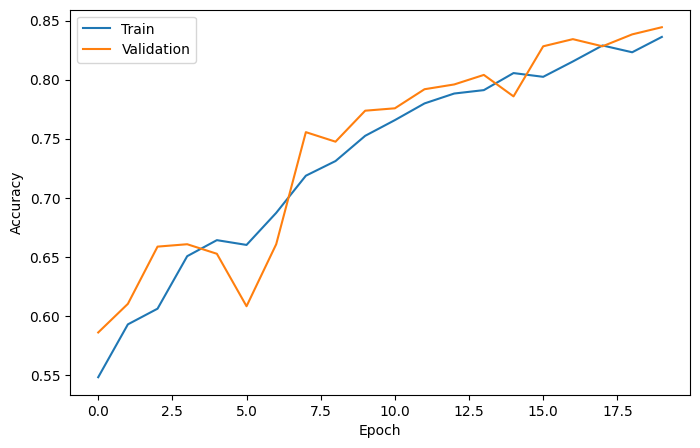

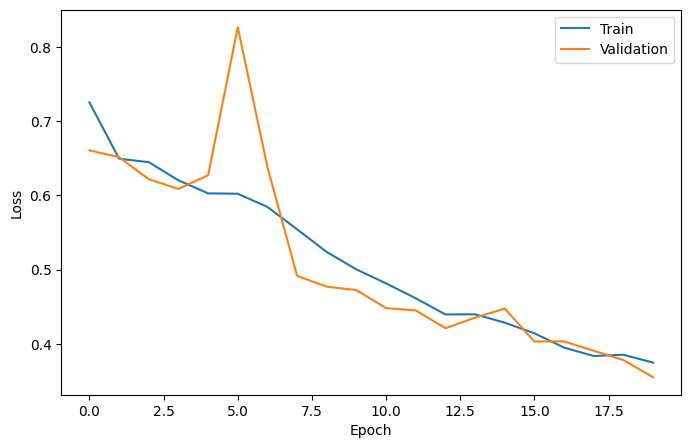

Validation Loss: 0.3551
Validation Accuracy: 0.8444
Test Loss: 0.3420
Test Accuracy: 0.8517


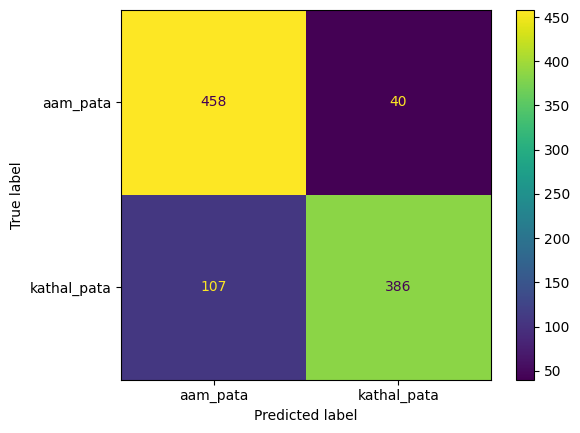

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot()

plt.show()